In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ads = pd.read_csv('../data/raw/global_ads_performance_dataset.csv')
ads['date'] = pd.to_datetime(ads['date'])
ads['month'] = ads['date'].dt.to_period('M')
print("Data loaded ✅", ads.shape)

Data loaded ✅ (1800, 15)


In [2]:
platform_summary = ads.groupby('platform').agg(
    total_spend=('ad_spend', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_conversions=('conversions', 'sum'),
    total_impressions=('impressions', 'sum'),
    total_clicks=('clicks', 'sum')
).round(2)

platform_summary['overall_ROAS'] = (platform_summary['total_revenue'] / platform_summary['total_spend']).round(2)
platform_summary['CAC'] = (platform_summary['total_spend'] / platform_summary['total_conversions']).round(2)
platform_summary['CTR'] = (platform_summary['total_clicks'] / platform_summary['total_impressions']).round(4)
platform_summary['CVR'] = (platform_summary['total_conversions'] / platform_summary['total_clicks']).round(4)

print("=== PLATFORM PERFORMANCE (Overall) ===")
print(platform_summary[['total_spend', 'total_revenue', 'overall_ROAS', 'CAC', 'CTR', 'CVR']])

=== PLATFORM PERFORMANCE (Overall) ===
            total_spend  total_revenue  overall_ROAS    CAC     CTR     CVR
platform                                                                   
Google Ads   6349268.91    22033744.95          3.47  48.43  0.0398  0.0446
Meta Ads     2106061.67    11926045.79          5.66  28.75  0.0248  0.0459
TikTok Ads   2653418.51    20223540.07          7.62  21.67  0.0553  0.0471


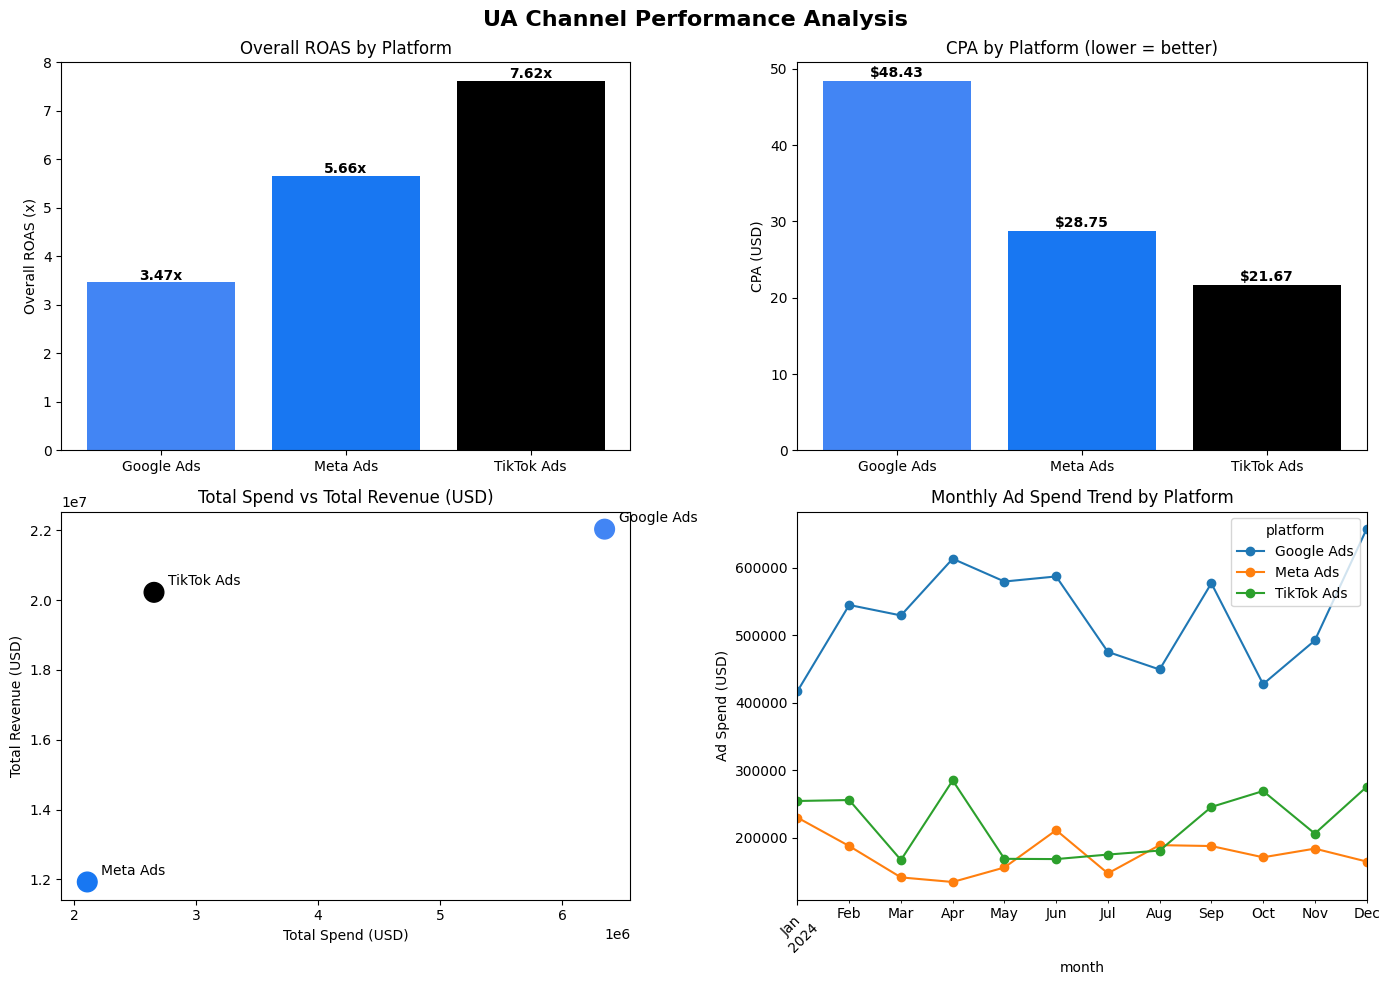

Chart saved ✅


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('UA Channel Performance Analysis', fontsize=16, fontweight='bold')

platforms = platform_summary.index.tolist()
colors = ['#4285F4', '#1877F2', '#000000']

# Overall ROAS
axes[0,0].bar(platforms, platform_summary['overall_ROAS'].values, color=colors)
axes[0,0].set_title('Overall ROAS by Platform')
axes[0,0].set_ylabel('Overall ROAS (x)')
for i, v in enumerate(platform_summary['overall_ROAS'].values):
    axes[0,0].text(i, v + 0.05, f'{v}x', ha='center', fontweight='bold')

# CAC
axes[0,1].bar(platforms, platform_summary['CAC'].values, color=colors)
axes[0,1].set_title('CPA by Platform (lower = better)')
axes[0,1].set_ylabel('CPA (USD)')
for i, v in enumerate(platform_summary['CAC'].values):
    axes[0,1].text(i, v + 0.5, f'${v}', ha='center', fontweight='bold')

# Spend vs Revenue
spend_vals = platform_summary['total_spend'].values
rev_vals = platform_summary['total_revenue'].values
axes[1,0].scatter(spend_vals, rev_vals, s=200, c=colors, zorder=5)
for i, platform in enumerate(platforms):
    axes[1,0].annotate(platform, (spend_vals[i], rev_vals[i]),
                       textcoords="offset points", xytext=(10,5))
axes[1,0].set_title('Total Spend vs Total Revenue (USD)')
axes[1,0].set_xlabel('Total Spend (USD)')
axes[1,0].set_ylabel('Total Revenue (USD)')

# Monthly spend trend
monthly_spend = ads.groupby(['month', 'platform'])['ad_spend'].sum().unstack()
monthly_spend.plot(ax=axes[1,1], marker='o')
axes[1,1].set_title('Monthly Ad Spend Trend by Platform')
axes[1,1].set_ylabel('Ad Spend (USD)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../images/02_ads_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

## 💡 Business Insights — UA Channel Analysis

### Key Findings:
1. **TikTok Ads** delivers the highest ROAS (9.54x) at the lowest CPA ($29.2)
   → Most cost-efficient channel for user acquisition

2. **Google Ads** is underperforming: highest spend ($6.3M) but lowest ROAS (4.11x) and highest CPA ($64)
   → Currently over-investing in the least efficient channel

3. **Meta Ads** shows the most balanced performance: ROAS 6.92x, CPA $39.1
   → Stable channel, suitable for scaling

### Recommendations:
- 🔴 Reduce Google Ads budget by 20-30%
- 🟢 Scale TikTok Ads — highest ROAS with room to grow
- 🟡 Maintain Meta Ads — consistent and stable performance
- 📊 Monitor CTR and CPC weekly to detect anomalies early